<a href="https://colab.research.google.com/github/ArduinoPLUS/aicar/blob/main/CNNACAdamCntF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

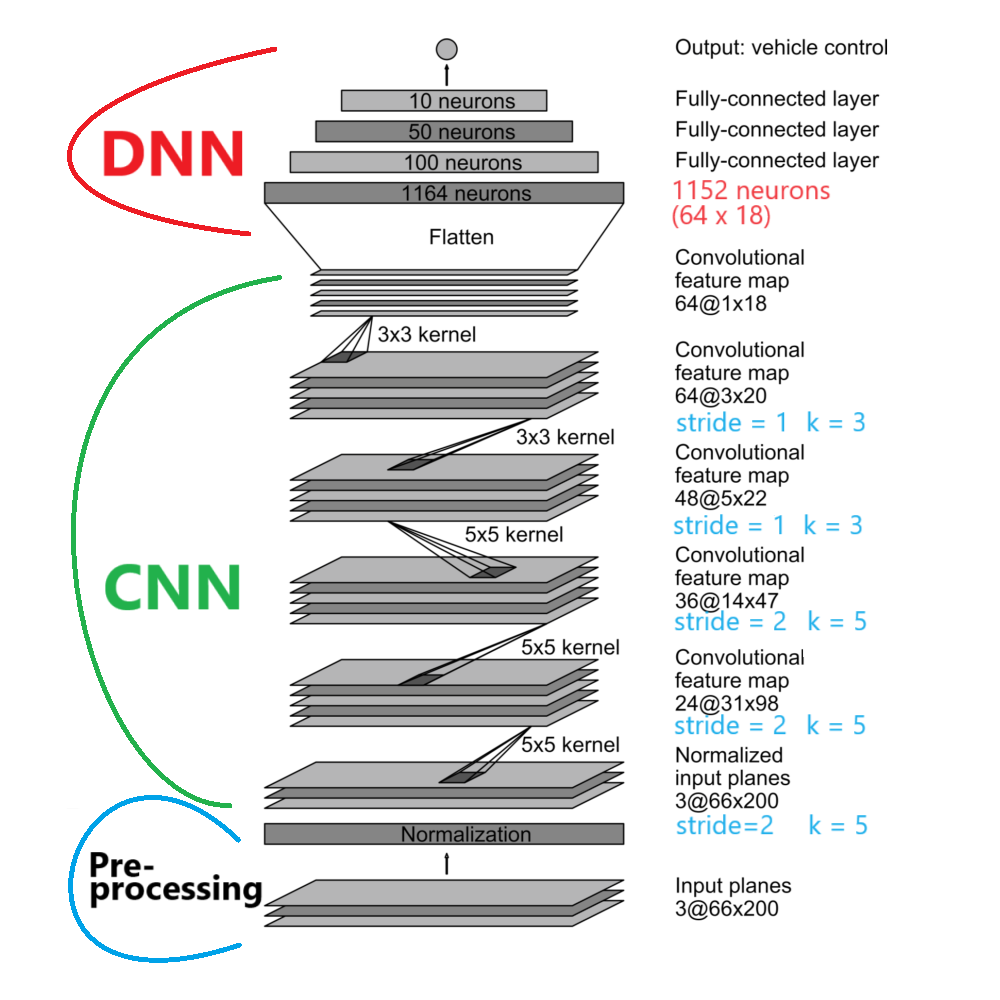

In [ ]:
#  End-to-End Deep Learning for Self-Driving Cars        - CNNACAdamCntF.ipynb -
import glob, zipfile
from google.colab import drive
drive.mount('/content/drive')           # Google Drive 연결
outDir = '/content/drive/MyDrive/'      # Google Drive 에서 저장 위치
fileList = glob.glob(outDir+'/*.zip'); print(f'자율주행 프로젝트는 {len(fileList)} 개 입니다.')
for t in fileList:                                         # 프로젝트 이름 프린트
  u = t.split('/'); v = u[-1]; w = v.split('.'); p = w[-2]; print(p) # 파일 이름 추출
project = input('자율주행 프로젝트 이름을 입력하세요:')    # 프로젝트 입력하고 [Enter]
if project == '': project = p                              # 마지막 파일을 사용
local_zip =  '/content/drive/MyDrive/'+project+'.zip'; print(local_zip) # Zip 경로(path)
zip_ref = zipfile.ZipFile(local_zip, 'r'); zip_ref.extractall(); zip_ref.close()

Mounted at /content/drive
자율주행 프로젝트는 7 개 입니다.
workE
wayA
myWay
mhtA
md
TDA
ympark
자율주행 프로젝트 이름을 입력하세요:myWay
/content/drive/MyDrive/myWay.zip


In [ ]:
epochs = 400                                  # 최대 학습회수
learning_rate =0.0001                         # 학습율
early_stopping_patience = 150                  # 조기 종료
MaxLearningTime = 60*60*10                    # 60*60*10  # 10 시간 학습 / 학습 가능 시간(초 단위)
#MaxLearningTime = 60*5                    # 60*60*10  # 10 시간 학습 / 학습 가능 시간(초 단위)
DIVMUL = 10                                   # Divide Multiply Factor
on_air = '_ON_AIR'

import os
import time
import datetime
import cv2
import zipfile
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import convolve2d

np.random.seed(12)  # Set a random seed for reproducibility

# 현재 UTC(GMT) 시간 가져오기 --------------------------------------------------
def getDateTime():
  gmt_now = datetime.datetime.now(datetime.UTC)
  # KST (한국 표준시)는 GMT+9 시간입니다.
  kst_now = gmt_now + datetime.timedelta(hours=9)
  # 요일을 한글로 매핑
  korean_weekdays = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일'] # weekday()는 0:월요일
  weekday_korean = korean_weekdays[kst_now.weekday()]
  # 오전/오후를 한글로 매핑
  am_pm_korean = '오전' if kst_now.hour < 12 else '오후'
  # 12시간 형식의 시간 (오전/오후와 함께 사용)
  hour_12 = kst_now.strftime('%I')
  # 최종 출력 문자열 구성
  formatted_kst_time = f"{kst_now.year}년 {kst_now.month}월 {kst_now.day}일 ({weekday_korean}) {am_pm_korean} {hour_12}시 {kst_now.minute}분 {kst_now.second}초"
  #print(f"현재 GMT 시간: {gmt_now.strftime('%Y년 %m월 %d일 %H시 %M분 %S초')}")
  #print(f"한국 표준시 (KST): {formatted_kst_time}")
  return(formatted_kst_time)

startLearn = time.time()                              # 프로그램 시작 시각

# 이미지 데이터 조향각 추출
with open(f'{project}/_{project}.pickle', 'rb') as f: # pickle 파일
    x_test_Image = pickle.load(f)                     # 시험(Test) 이미지 파일 이름 리스트
    x_valid_Image = pickle.load(f)                    # 검증(Valid) 이미지 파일 이름 리스트
    x_train_Image = pickle.load(f)                    # 훈련(Train) 이미지 파일 이름 리스트
#-------------------------------------------------------------------------------
y_test_Angle=[]
y_valid_Angle=[]
y_train_Angle = []
for f in x_test_Image:                                # 시험용 이미지 파일 이름에서 각도값
    y_test_Angle.append(float(f[-7:-4])/DIVMUL)       # 학습 가능 범위로 수정
for f in x_valid_Image:                               # 검증용 이미지 파일 이름에서 각도값
    y_valid_Angle.append(float(f[-7:-4])/DIVMUL)      # 학습 가능 범위로 수정
for f in x_train_Image:                               # 훈련용 이미지 파일 이름에서 각도값
    y_train_Angle.append(float(f[-7:-4])/DIVMUL)      # 학습 가능 범위로 수정

print('시험 이미지 개수:',len(x_test_Image),'\n',x_test_Image,'\n',y_test_Angle)
print('검증 이미지 개수:',len(x_valid_Image),'\n',x_valid_Image,'\n',y_valid_Angle)
print('훈련 이미지 개수:',len(x_train_Image),'\n',x_train_Image,'\n',y_train_Angle)


시험 이미지 개수: 7 
 ['P0916__-55.png', 'P0830__-26.png', 'P0999__-13.png', 'P0570__+03.png', 'P0161__+16.png', 'P0484__+26.png', 'P1025__+50.png'] 
 [-5.5, -2.6, -1.3, 0.3, 1.6, 2.6, 5.0]
검증 이미지 개수: 485 
 ['P0719__-49.png', 'P0823__-25.png', 'P0269__-24.png', 'P0717__-45.png', 'P0720__-45.png', 'P0284__-26.png', 'P0183__-43.png', 'P0727__-38.png', 'P0849__-23.png', 'P0713__-39.png', 'P0192__-33.png', 'P0934__-37.png', 'P0854__-26.png', 'P0378__-39.png', 'P0710__-25.png', 'P0729__-35.png', 'P0935__-30.png', 'P0664__-25.png', 'P0275__-23.png', 'P0288__-25.png', 'P0367__-35.png', 'P0912__-39.png', 'P0814__-26.png', 'P0827__-25.png', 'P0732__-28.png', 'P0271__-24.png', 'P0915__-45.png', 'P0280__-26.png', 'P0281__-26.png', 'P0385__-41.png', 'P0746__-29.png', 'P0306__-25.png', 'P0724__-44.png', 'P0670__-38.png', 'P0931__-40.png', 'P0820__-25.png', 'P0202__-27.png', 'P0311__-24.png', 'P0906__-31.png', 'P0750__-33.png', 'P0669__-38.png', 'P0842__-24.png', 'P0186__-43.png', 'P0816__-25.png', 'P0673_

In [ ]:
# ELU 활성화 함수 및 미분
'''
def elu(x, alpha=1.0):
  """ELU activation function"""
  return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def elu_derivative(x, alpha=1.0):
  """ELU derivative"""
  return np.where(x > 0, 1, alpha * np.exp(x))
'''

# Safe ELU, Derivative ---------------------------------------------------------
def elu(x, alpha=1.0):
    # np.where는 조건에 따라 선택할 두 식을 모두 계산하므로,
    # x > 0 일 때도 np.exp(x)가 계산되어 오버플로우를 유발할 수 있습니다.
    # 이를 방지하기 위해 x <= 0 인 경우에만 np.exp를 적용하도록 수정합니다.

    # 결과 배열을 0으로 초기화합니다.
    result = np.zeros_like(x, dtype=x.dtype)

    # x > 0 인 경우: result = x
    pos_mask = x > 0         # print('PM',pos_mask)
    result[pos_mask] = x[pos_mask]

    # x <= 0 인 경우: result = alpha * (exp(x) - 1)
    neg_mask = x <= 0        # print('NM',neg_mask)
    result[neg_mask] = alpha * (np.exp(x[neg_mask]) - 1)

    return result

def elu_derivative(x, alpha=1.0):
    # ELU 함수의 미분은 다음과 같이 정의됩니다:
    # x > 0 일 때: f'(x) = 1
    # x <= 0 일 때: f'(x) = alpha * exp(x)

    # 결과 배열을 0으로 초기화합니다.
    result = np.zeros_like(x, dtype=x.dtype)

    # x > 0 인 경우: result = 1
    pos_mask = x > 0
    result[pos_mask] = 1.0

    # x <= 0 인 경우: result = alpha * exp(x)
    neg_mask = x <= 0
    result[neg_mask] = alpha * np.exp(x[neg_mask])

    return result


#===============================================================================
class FlexibleCNN:

  def __init__(self, in_channels, out_channels, kernel_size, stride=1, T=''):
    self.in_channels = in_channels
    self.out_channels = out_channels
    self.kernel_size = kernel_size
    self.stride = stride
    self.kernel = np.random.randn(out_channels, in_channels, kernel_size[0], kernel_size[1]) * 0.1
    self.bias = np.random.randn(out_channels) * 0.1

    # Early stop return parameter
    self.skernel = np.zeros_like(self.kernel)
    self.sbias = np.zeros_like(self.bias)

    # Adam Optimizer 파라미터 초기화
    self.m_kernel = np.zeros_like(self.kernel)  # 1차 모멘트 (평균)
    self.v_kernel = np.zeros_like(self.kernel)  # 2차 모멘트 (분산)
    self.m_bias = np.zeros_like(self.bias)
    self.v_bias = np.zeros_like(self.bias)
    self.t = 0  # 타임스텝

    # Adam 하이퍼파라미터
    self.beta1 = 0.9
    self.beta2 = 0.999
    self.epsilon = 1e-8

    print(f'FlexibleCNN Initialization {T}:')
    print(f'Input Channels:{in_channels}  Output Channels:{out_channels} F:{in_channels * out_channels} Kernel Size:{kernel_size} Stride: {stride}')
    print(f'{"="*76}')

    self.input = None
    self.conv_out = None
    self.activation_out = None

  def _calculate_output_size(self, input_size):   # 컨볼류션 연산후 이미지 출력 크기
    H_in, W_in = input_size                     # 이미지의 Height, Width
    H_k, W_k = self.kernel_size                 # kernel 크기
    H_valid = H_in - H_k + 1                    # 입력 H - kernel H
    W_valid = W_in - W_k + 1                    # 입력 W - kernel W
    H_out = (H_valid + self.stride - 1) // self.stride  # 출력 Height
    W_out = (W_valid + self.stride - 1) // self.stride  # 출력 Width
    return (H_out, W_out)                               # 출력 크기 반환

  def forward(self, X):                           # 순전파
    self.input = X                              # 입력 이미지 저장
    H_in, W_in = X.shape[1], X.shape[2]         # 이미지의 Height, Width (C, H, W)
    H_out, W_out = self._calculate_output_size((H_in, W_in))    # 출력 크기 계산
    self.conv_out = np.zeros((self.out_channels, H_out, W_out)) # 출력채널 수, H, W

    for out_ch in range(self.out_channels):     # 출력 채널 개수
      temp_sum = np.zeros((H_in - self.kernel_size[0] + 1, W_in - self.kernel_size[1] + 1))
      for in_ch in range(self.in_channels):   # 입력 채널 개수
        # 입력 채널과 kernel의 교차상관(컨볼류션) 연산, 출력 kernel 에 입력 채널 합산
        temp_sum += convolve2d(X[in_ch], np.rot90(self.kernel[out_ch, in_ch], k=2), mode='valid')
      # 스트라이드, bias
      self.conv_out[out_ch] = temp_sum[::self.stride, ::self.stride] + self.bias[out_ch]

    self.activation_out = elu(self.conv_out)    # ELU 활성화 함수
    return self.activation_out

  def backward(self, dL_dout, learning_rate):                # 역전파
    dL_dconv = dL_dout * elu_derivative(self.conv_out)     # 오차 변화율 x 활성화 함수 출력(ELU)의 미분

    H_in, W_in = self.input.shape[1], self.input.shape[2]  # 입력 이미지의 Height, Width
    H_valid = H_in - self.kernel_size[0] + 1               # Height zero padding
    W_valid = W_in - self.kernel_size[1] + 1               # Width  zero padding
    dL_dconv_upsampled = np.zeros((self.out_channels, H_valid, W_valid))   # 비어있는 이미지 Up sample
    dL_dconv_upsampled[:, ::self.stride, ::self.stride] = dL_dconv         # Up sample

    dkernel = np.zeros_like(self.kernel)                   # kernel 과 같은 크기의 그래디언트 kernel
    dbias = np.sum(dL_dconv, axis=(1, 2))                  # 채널당 1 개의 bias
    dL_dX = np.zeros_like(self.input)                      # 입력 X 크기와 같은 크기의 입력 X 변화율에 대한 오차변화율

    for out_ch in range(self.out_channels):                # 출력 채널 개수
      for in_ch in range(self.in_channels):              # 입력 출력 개수
        dkernel[out_ch, in_ch] = convolve2d(self.input[in_ch], np.rot90(dL_dconv_upsampled[out_ch], k=2), mode='valid')
        padded_gradient = np.pad(dL_dconv_upsampled[out_ch],
                                pad_width=((self.kernel_size[0]-1, self.kernel_size[0]-1),
                                            (self.kernel_size[1]-1, self.kernel_size[1]-1)),
                                mode='constant')
        dL_dX[in_ch] += convolve2d(padded_gradient, self.kernel[out_ch, in_ch], mode='valid')

    # Adam Optimizer 업데이트
    self.t += 1

    # Kernel 업데이트
    self.m_kernel = self.beta1 * self.m_kernel + (1 - self.beta1) * dkernel
    self.v_kernel = self.beta2 * self.v_kernel + (1 - self.beta2) * (dkernel ** 2)
    m_kernel_hat = self.m_kernel / (1 - self.beta1 ** self.t)
    v_kernel_hat = self.v_kernel / (1 - self.beta2 ** self.t)
    self.kernel -= learning_rate * m_kernel_hat / (np.sqrt(v_kernel_hat) + self.epsilon)

    # Bias 업데이트
    self.m_bias = self.beta1 * self.m_bias + (1 - self.beta1) * dbias
    self.v_bias = self.beta2 * self.v_bias + (1 - self.beta2) * (dbias ** 2)
    m_bias_hat = self.m_bias / (1 - self.beta1 ** self.t)
    v_bias_hat = self.v_bias / (1 - self.beta2 ** self.t)
    self.bias -= learning_rate * m_bias_hat / (np.sqrt(v_bias_hat) + self.epsilon)

    return dL_dX

#-------------------------------------------------------------------------------
class DNN:

  def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, output_size):

    self.input_size = input_size
    self.hidden_size1 = hidden_size1
    self.hidden_size2 = hidden_size2
    self.hidden_size3 = hidden_size3
    self.output_size = output_size

    self.W1 = np.random.randn(self.input_size, self.hidden_size1) * np.sqrt(2 / self.input_size)
    self.B1 = np.zeros((1, self.hidden_size1))
    self.W2 = np.random.randn(self.hidden_size1, self.hidden_size2) * np.sqrt(2 / self.hidden_size1)
    self.B2 = np.zeros((1, self.hidden_size2))
    self.W3 = np.random.randn(self.hidden_size2, self.hidden_size3) * np.sqrt(2 / self.hidden_size2)
    self.B3 = np.zeros((1, self.hidden_size3))
    self.W4 = np.random.randn(self.hidden_size3, self.output_size) * np.sqrt(2 / self.hidden_size3)
    self.B4 = np.zeros((1, self.output_size))

    # Early stop return parameter
    self.sW1 = np.zeros_like(self.W1)
    self.sB1 = np.zeros_like(self.B1)
    self.sW2 = np.zeros_like(self.W2)
    self.sB2 = np.zeros_like(self.B2)
    self.sW3 = np.zeros_like(self.W3)
    self.sB3 = np.zeros_like(self.B3)
    self.sW4 = np.zeros_like(self.W4)
    self.sB4 = np.zeros_like(self.B4)

    # Adam Optimizer 파라미터 초기화
    self.m_W1 = np.zeros_like(self.W1)
    self.v_W1 = np.zeros_like(self.W1)
    self.m_B1 = np.zeros_like(self.B1)
    self.v_B1 = np.zeros_like(self.B1)

    self.m_W2 = np.zeros_like(self.W2)
    self.v_W2 = np.zeros_like(self.W2)
    self.m_B2 = np.zeros_like(self.B2)
    self.v_B2 = np.zeros_like(self.B2)

    self.m_W3 = np.zeros_like(self.W3)
    self.v_W3 = np.zeros_like(self.W3)
    self.m_B3 = np.zeros_like(self.B3)
    self.v_B3 = np.zeros_like(self.B3)

    self.m_W4 = np.zeros_like(self.W4)
    self.v_W4 = np.zeros_like(self.W4)
    self.m_B4 = np.zeros_like(self.B4)
    self.v_B4 = np.zeros_like(self.B4)

    self.t = 0  # 타임스텝

    # Adam 하이퍼파라미터
    self.beta1 = 0.9
    self.beta2 = 0.999
    self.epsilon = 1e-8

  def forward(self, X):

    self.Z1 = np.dot(X, self.W1) + self.B1
    self.A1 = elu(self.Z1)
    self.Z2 = np.dot(self.A1, self.W2) + self.B2
    self.A2 = elu(self.Z2)
    self.Z3 = np.dot(self.A2, self.W3) + self.B3
    self.A3 = elu(self.Z3)
    self.Z4 = np.dot(self.A3, self.W4) + self.B4
    self.Y_hat = self.Z4
    return self.Y_hat

  def backward(self, X, Y, learning_rate):

    D4 = (self.Y_hat - Y)
    dW4 = np.dot(self.A3.T, D4)
    dB4 = np.sum(D4, axis=0, keepdims=True)

    D3 = np.dot(D4, self.W4.T) * elu_derivative(self.Z3)
    dW3 = np.dot(self.A2.T, D3)
    dB3 = np.sum(D3, axis=0, keepdims=True)

    D2 = np.dot(D3, self.W3.T) * elu_derivative(self.Z2)
    dW2 = np.dot(self.A1.T, D2)
    dB2 = np.sum(D2, axis=0, keepdims=True)

    D1 = np.dot(D2, self.W2.T) * elu_derivative(self.Z1)
    dW1 = np.dot(X.T, D1)
    dB1 = np.sum(D1, axis=0, keepdims=True)

    dL_dX = np.dot(D1, self.W1.T)

    # Adam Optimizer 업데이트
    self.t += 1

    # W4, B4 업데이트
    self.m_W4 = self.beta1 * self.m_W4 + (1 - self.beta1) * dW4
    self.v_W4 = self.beta2 * self.v_W4 + (1 - self.beta2) * (dW4 ** 2)
    m_W4_hat = self.m_W4 / (1 - self.beta1 ** self.t)
    v_W4_hat = self.v_W4 / (1 - self.beta2 ** self.t)
    self.W4 -= learning_rate * m_W4_hat / (np.sqrt(v_W4_hat) + self.epsilon)

    self.m_B4 = self.beta1 * self.m_B4 + (1 - self.beta1) * dB4
    self.v_B4 = self.beta2 * self.v_B4 + (1 - self.beta2) * (dB4 ** 2)
    m_B4_hat = self.m_B4 / (1 - self.beta1 ** self.t)
    v_B4_hat = self.v_B4 / (1 - self.beta2 ** self.t)
    self.B4 -= learning_rate * m_B4_hat / (np.sqrt(v_B4_hat) + self.epsilon)

    # W3, B3 업데이트
    self.m_W3 = self.beta1 * self.m_W3 + (1 - self.beta1) * dW3
    self.v_W3 = self.beta2 * self.v_W3 + (1 - self.beta2) * (dW3 ** 2)
    m_W3_hat = self.m_W3 / (1 - self.beta1 ** self.t)
    v_W3_hat = self.v_W3 / (1 - self.beta2 ** self.t)
    self.W3 -= learning_rate * m_W3_hat / (np.sqrt(v_W3_hat) + self.epsilon)

    self.m_B3 = self.beta1 * self.m_B3 + (1 - self.beta1) * dB3
    self.v_B3 = self.beta2 * self.v_B3 + (1 - self.beta2) * (dB3 ** 2)
    m_B3_hat = self.m_B3 / (1 - self.beta1 ** self.t)
    v_B3_hat = self.v_B3 / (1 - self.beta2 ** self.t)
    self.B3 -= learning_rate * m_B3_hat / (np.sqrt(v_B3_hat) + self.epsilon)

    # W2, B2 업데이트
    self.m_W2 = self.beta1 * self.m_W2 + (1 - self.beta1) * dW2
    self.v_W2 = self.beta2 * self.v_W2 + (1 - self.beta2) * (dW2 ** 2)
    m_W2_hat = self.m_W2 / (1 - self.beta1 ** self.t)
    v_W2_hat = self.v_W2 / (1 - self.beta2 ** self.t)
    self.W2 -= learning_rate * m_W2_hat / (np.sqrt(v_W2_hat) + self.epsilon)

    self.m_B2 = self.beta1 * self.m_B2 + (1 - self.beta1) * dB2
    self.v_B2 = self.beta2 * self.v_B2 + (1 - self.beta2) * (dB2 ** 2)
    m_B2_hat = self.m_B2 / (1 - self.beta1 ** self.t)
    v_B2_hat = self.v_B2 / (1 - self.beta2 ** self.t)
    self.B2 -= learning_rate * m_B2_hat / (np.sqrt(v_B2_hat) + self.epsilon)

    # W1, B1 업데이트
    self.m_W1 = self.beta1 * self.m_W1 + (1 - self.beta1) * dW1
    self.v_W1 = self.beta2 * self.v_W1 + (1 - self.beta2) * (dW1 ** 2)
    m_W1_hat = self.m_W1 / (1 - self.beta1 ** self.t)
    v_W1_hat = self.v_W1 / (1 - self.beta2 ** self.t)
    self.W1 -= learning_rate * m_W1_hat / (np.sqrt(v_W1_hat) + self.epsilon)

    self.m_B1 = self.beta1 * self.m_B1 + (1 - self.beta1) * dB1
    self.v_B1 = self.beta2 * self.v_B1 + (1 - self.beta2) * (dB1 ** 2)
    m_B1_hat = self.m_B1 / (1 - self.beta1 ** self.t)
    v_B1_hat = self.v_B1 / (1 - self.beta2 ** self.t)
    self.B1 -= learning_rate * m_B1_hat / (np.sqrt(v_B1_hat) + self.epsilon)

    return dL_dX


In [ ]:
def load_parameter(cnnA, cnnB, cnnC, cnnD, cnnE, dnn):

  with open(f'/content/drive/MyDrive/{project}.pickle', 'rb') as f:

    # CNN Kernel, Bias Load, Adam Optimizer
    cnnA.t = pickle.load(f)
    cnnA.m_kernel = pickle.load(f); cnnA.v_kernel = pickle.load(f); cnnA.kernel = pickle.load(f)
    cnnA.m_bias = pickle.load(f); cnnA.v_bias = pickle.load(f); cnnA.bias = pickle.load(f)

    cnnB.t = pickle.load(f)
    cnnB.m_kernel = pickle.load(f); cnnB.v_kernel = pickle.load(f); cnnB.kernel = pickle.load(f)
    cnnB.m_bias = pickle.load(f); cnnB.v_bias = pickle.load(f); cnnB.bias = pickle.load(f)

    cnnC.t = pickle.load(f)
    cnnC.m_kernel = pickle.load(f); cnnC.v_kernel = pickle.load(f); cnnC.kernel = pickle.load(f)
    cnnC.m_bias = pickle.load(f); cnnC.v_bias = pickle.load(f); cnnC.bias = pickle.load(f)

    cnnD.t = pickle.load(f)
    cnnD.m_kernel = pickle.load(f); cnnD.v_kernel = pickle.load(f); cnnD.kernel = pickle.load(f)
    cnnD.m_bias = pickle.load(f); cnnD.v_bias = pickle.load(f); cnnD.bias = pickle.load(f)

    cnnE.t = pickle.load(f)
    cnnE.m_kernel = pickle.load(f); cnnE.v_kernel = pickle.load(f); cnnE.kernel = pickle.load(f)
    cnnE.m_bias = pickle.load(f); cnnE.v_bias = pickle.load(f); cnnE.bias = pickle.load(f)

    cnnA.skernel = pickle.load(f); cnnA.sbias = pickle.load(f)
    cnnB.skernel = pickle.load(f); cnnB.sbias = pickle.load(f)
    cnnC.skernel = pickle.load(f); cnnC.sbias = pickle.load(f)
    cnnD.skernel = pickle.load(f); cnnD.sbias = pickle.load(f)
    cnnE.skernel = pickle.load(f); cnnE.sbias = pickle.load(f)

    # Adam Optimizer
    dnn.t = pickle.load(f)
    # W4, B4
    dnn.m_W4 = pickle.load(f); dnn.v_W4 = pickle.load(f); dnn.W4 = pickle.load(f)
    dnn.m_B4 = pickle.load(f); dnn.v_B4 = pickle.load(f); dnn.B4 = pickle.load(f)
    # W3, B3
    dnn.m_W3 = pickle.load(f); dnn.v_W3 = pickle.load(f); dnn.W3 = pickle.load(f)
    dnn.m_B3 = pickle.load(f); dnn.v_B3 = pickle.load(f); dnn.B3 = pickle.load(f)
    # W2, B2
    dnn.m_W2 = pickle.load(f); dnn.v_W2 = pickle.load(f); dnn.W2 = pickle.load(f)
    dnn.m_B2 = pickle.load(f); dnn.v_B2 = pickle.load(f); dnn.B2 = pickle.load(f)
    # W1, B1
    dnn.m_W1 = pickle.load(f); dnn.v_W1 = pickle.load(f); dnn.W1 = pickle.load(f)
    dnn.m_B1 = pickle.load(f); dnn.v_B1 = pickle.load(f); dnn.B1 = pickle.load(f)

    dnn.sW1 = pickle.load(f); dnn.sB1 = pickle.load(f)
    dnn.sW2 = pickle.load(f); dnn.sB2 = pickle.load(f)
    dnn.sW3 = pickle.load(f); dnn.sB3 = pickle.load(f)
    dnn.sW4 = pickle.load(f); dnn.sB4 = pickle.load(f)

    train_loss_at_val_lowest = pickle.load(f)
    valid_avg_loss_prev = pickle.load(f)
    train_loss_history = pickle.load(f)
    valid_loss_history = pickle.load(f)
    std_out = pickle.load(f)
    early_stop_count = pickle.load(f)
    acc_epoch = pickle.load(f)
    acc_learn_time = pickle.load(f)
    final_epoch = pickle.load(f)

  return  train_loss_at_val_lowest, valid_avg_loss_prev, train_loss_history,\
  valid_loss_history, std_out, early_stop_count, acc_epoch, acc_learn_time, final_epoch

# Save Parameter----------------------------------------------------------------
def save_parameter(cnnA, cnnB, cnnC, cnnD, cnnE, dnn,
                   train_loss_at_val_lowest, valid_avg_loss_prev, train_loss_history, valid_loss_history, std_out,
                   early_stop_count, acc_epoch, acc_learn_time, final_epoch):

  fileName = f'/content/drive/MyDrive/{project}.pickle'
  with open(fileName, 'wb') as f:

    # Adam Optimizer 업데이트
    pickle.dump(cnnA.t, f)
    pickle.dump(cnnA.m_kernel, f); pickle.dump(cnnA.v_kernel, f); pickle.dump(cnnA.kernel, f)
    pickle.dump(cnnA.m_bias, f); pickle.dump(cnnA.v_bias, f); pickle.dump(cnnA.bias, f)

    pickle.dump(cnnB.t, f)
    pickle.dump(cnnB.m_kernel, f); pickle.dump(cnnB.v_kernel, f); pickle.dump(cnnB.kernel, f)
    pickle.dump(cnnB.m_bias, f); pickle.dump(cnnB.v_bias, f); pickle.dump(cnnB.bias, f)

    pickle.dump(cnnC.t, f)
    pickle.dump(cnnC.m_kernel, f); pickle.dump(cnnC.v_kernel, f); pickle.dump(cnnC.kernel, f)
    pickle.dump(cnnC.m_bias, f); pickle.dump(cnnC.v_bias, f); pickle.dump(cnnC.bias, f)

    pickle.dump(cnnD.t, f)
    pickle.dump(cnnD.m_kernel, f); pickle.dump(cnnD.v_kernel, f); pickle.dump(cnnD.kernel, f)
    pickle.dump(cnnD.m_bias, f); pickle.dump(cnnD.v_bias, f); pickle.dump(cnnD.bias, f)

    pickle.dump(cnnE.t, f)
    pickle.dump(cnnE.m_kernel, f); pickle.dump(cnnE.v_kernel, f); pickle.dump(cnnE.kernel, f);
    pickle.dump(cnnE.m_bias, f); pickle.dump(cnnE.v_bias, f); pickle.dump(cnnE.bias, f)

    pickle.dump(cnnA.skernel, f); pickle.dump(cnnA.sbias, f)
    pickle.dump(cnnB.skernel, f); pickle.dump(cnnB.sbias, f)
    pickle.dump(cnnC.skernel, f); pickle.dump(cnnC.sbias, f)
    pickle.dump(cnnD.skernel, f); pickle.dump(cnnD.sbias, f)
    pickle.dump(cnnE.skernel, f); pickle.dump(cnnE.sbias, f)

    # Adam Optimizer 업데이트
    pickle.dump(dnn.t, f)
    # W4, B4 업데이트
    pickle.dump(dnn.m_W4, f); pickle.dump(dnn.v_W4, f); pickle.dump(dnn.W4, f)
    pickle.dump(dnn.m_B4, f); pickle.dump(dnn.v_B4, f); pickle.dump(dnn.B4, f)
    # W3, B3 업데이트
    pickle.dump(dnn.m_W3, f); pickle.dump(dnn.v_W3, f); pickle.dump(dnn.W3, f)
    pickle.dump(dnn.m_B3, f); pickle.dump(dnn.v_B3, f); pickle.dump(dnn.B3, f)
    # W2, B2 업데이트
    pickle.dump(dnn.m_W2, f); pickle.dump(dnn.v_W2, f); pickle.dump(dnn.W2, f)
    pickle.dump(dnn.m_B2, f); pickle.dump(dnn.v_B2, f); pickle.dump(dnn.B2, f)
    # W1, B1 업데이트
    pickle.dump(dnn.m_W1, f); pickle.dump(dnn.v_W1, f); pickle.dump(dnn.W1, f)
    pickle.dump(dnn.m_B1, f); pickle.dump(dnn.v_B1, f); pickle.dump(dnn.B1, f)

    pickle.dump(dnn.sW1, f); pickle.dump(dnn.sB1, f)
    pickle.dump(dnn.sW2, f); pickle.dump(dnn.sB2, f)
    pickle.dump(dnn.sW3, f); pickle.dump(dnn.sB3, f)
    pickle.dump(dnn.sW4, f); pickle.dump(dnn.sB4, f)

    pickle.dump(train_loss_at_val_lowest, f)
    pickle.dump(valid_avg_loss_prev, f)
    pickle.dump(train_loss_history, f)
    pickle.dump(valid_loss_history, f)
    pickle.dump(std_out, f)
    pickle.dump(early_stop_count, f)
    pickle.dump(acc_epoch, f)
    pickle.dump(acc_learn_time, f)
    pickle.dump(final_epoch, f)

    return



############################################################################
Loading images and initializing model...
############################################################################

FlexibleCNN Initialization A:
Input Channels:3  Output Channels:24 F:72 Kernel Size:(5, 5) Stride: 2
FlexibleCNN Initialization B:
Input Channels:24  Output Channels:36 F:864 Kernel Size:(5, 5) Stride: 2
FlexibleCNN Initialization C:
Input Channels:36  Output Channels:48 F:1728 Kernel Size:(5, 5) Stride: 2
FlexibleCNN Initialization D:
Input Channels:48  Output Channels:64 F:3072 Kernel Size:(3, 3) Stride: 1
FlexibleCNN Initialization E:
Input Channels:64  Output Channels:64 F:4096 Kernel Size:(3, 3) Stride: 1
2026년 1월 15일 (목요일) 오후 08시 38분 26초
Starting training with 1939 images for 400 epochs

myWay.pickle file exists

Epoch: 1/300 - Train Loss: 1.05583286   Valid Loss: 22.99461178       T. 77: 14  Acc.T. 1:17:14
Epoch: 2/300 - Train Loss: 0.68927881   Valid Loss: 23.78485208
--------- Early 

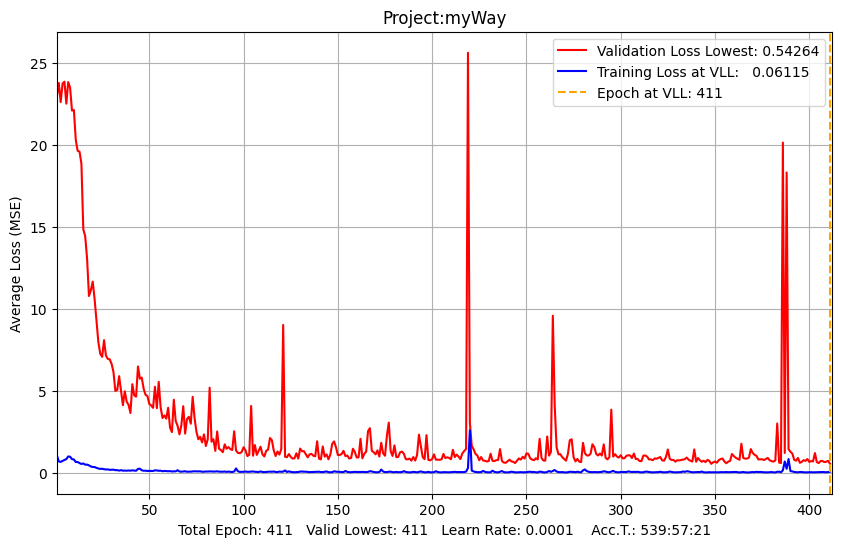

All training completed successfully!
2026년 1월 16일 (금요일) 오전 07시 10분 42초


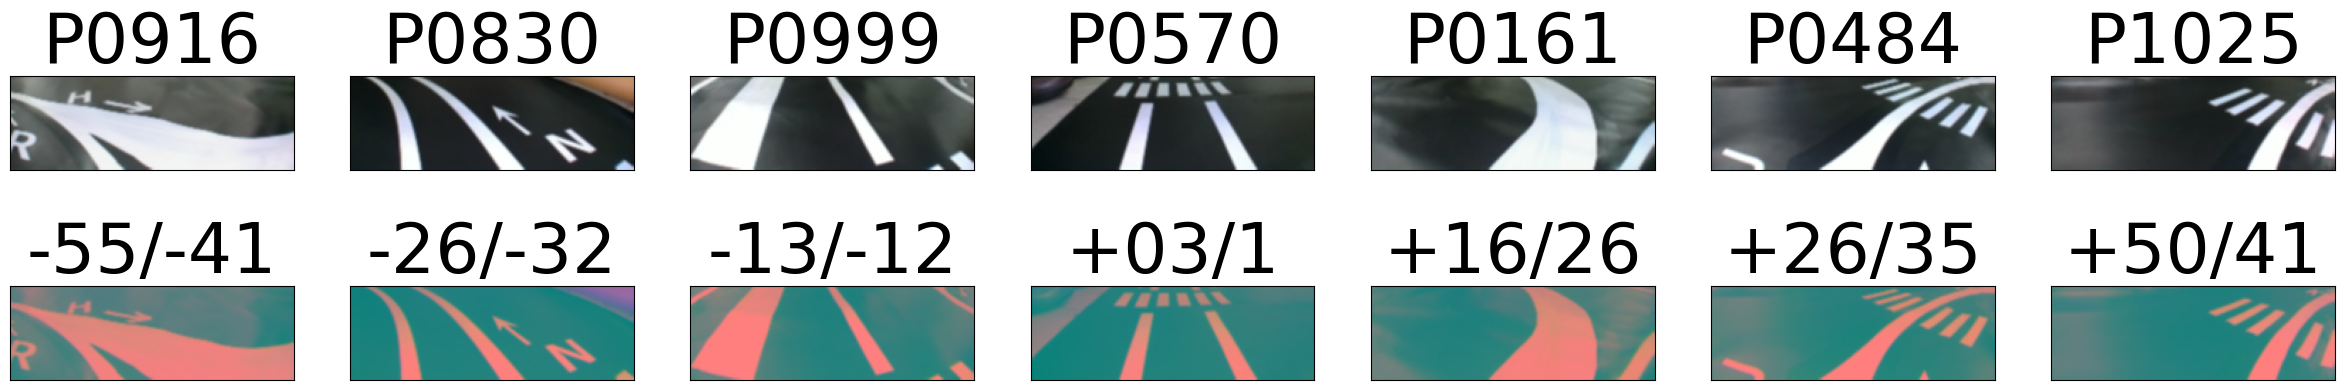

In [ ]:
#===============================================================================
def load_image(image_path):
    """이미지를 로드하고 CNN 입력 형태로 변환"""
    img = Image.open(image_path)
    img_array = np.array(img)

    if img_array.ndim == 3:
        img_array = img_array.transpose(2, 1, 0)
    elif img_array.ndim == 2:
        img_array = img_array[np.newaxis, :, :]

    if img_array.dtype == np.uint8:
        img_array = img_array / 255.0

    return img_array

#-------------------------------------------------------------------------------
def train_multi_images(image_dir,
                       train_dataX, train_angleY,
                       valid_dataX, valid_angleY,
                       test_dataX, test_angleY,
                       epochs, learning_rate):

    print(f'\n{"#"*76}')
    print("Loading images and initializing model...")
    print(f'{"#"*76}\n')

    # CNN 모델 생성
    cnnA = FlexibleCNN(in_channels=3, out_channels=24, kernel_size=(5, 5), stride=2, T='A')
    cnnB = FlexibleCNN(in_channels=24, out_channels=36, kernel_size=(5, 5), stride=2, T='B')
    cnnC = FlexibleCNN(in_channels=36, out_channels=48, kernel_size=(5, 5), stride=2, T='C')
    cnnD = FlexibleCNN(in_channels=48, out_channels=64, kernel_size=(3, 3), stride=1, T='D')
    cnnE = FlexibleCNN(in_channels=64, out_channels=64, kernel_size=(3, 3), stride=1, T='E')

    # DNN 모델 생성
    dnn = DNN(1152, 100, 50, 10, 1)    # CNNE 의 flatten후 출력 개수

    # train 이미지 로드
    train_images = []
    for t_img_name in train_dataX:
        t_img_path = os.path.join(image_dir, t_img_name)
        t_img_array = load_image(t_img_path)
        train_images.append(t_img_array)

    # valid 이미지 로드
    valid_images = []
    for v_img_name in valid_dataX:
        v_img_path = os.path.join(image_dir, v_img_name)
        v_img_array = load_image(v_img_path)
        valid_images.append(v_img_array)

    # test 이미지 로드
    test_images = []
    for e_img_name in test_dataX:
        e_img_path = os.path.join(image_dir, e_img_name)
        e_img_array = load_image(e_img_path)
        test_images.append(e_img_array)

    # Training
    valid_avg_loss_prev = float('inf')              # valid 평균손실 가장 낮은 값, 초기 값으로 무한대 설정
    train_loss_at_val_lowest = 0                    # valid 평균 손실이 최저였을 때 train 손실
    train_loss_history = [0,]                       # train loss
    valid_loss_history = [0,]                       # valid loss
    std_out = []                                    # Standard out string
    early_stop_count = 0                            # 조기 종료 카운트
    acc_epoch = 0                                   # 누적 학습회수
    acc_learn_time = 0                              # 누적 학습 소요 시간
    final_epoch = 0                                 # valid loss 최저일 때 epoch

    msgA = ''
    msgB = ''
    msgC = ''
    msgD = ''

    startLearn = time.time()
    print(getDateTime())

    print(f'{"="*76}')
    print(f'Starting training with {len(train_dataX)} images for {epochs} epochs')
    print(f'{"="*76}\n')
    #===========================================================================
    if glob.glob(f'/content/drive/MyDrive/{project}.pickle'):
        print(f'{project}.pickle file exists\n')
        train_loss_at_val_lowest, valid_avg_loss_prev, train_loss_history, valid_loss_history, std_out, early_stop_count, acc_epoch, acc_learn_time, final_epoch = load_parameter(cnnA, cnnB, cnnC, cnnD, cnnE, dnn)
        for t in std_out:
          print(t)
    else:
        print('\nNew Start')
        print(f'{"="*76}\n')
    #===========================================================================

    for epoch in range(epochs):
        startLoop = time.time()
        t_epoch_loss = 0
        # train 이미지에 대해 학습
        for idx, (img, target_val) in enumerate(zip(train_images, train_angleY)):
            target = np.array([[target_val]])

            # Forward
            cnn_outA = cnnA.forward(img)
            cnn_outB = cnnB.forward(cnn_outA)
            cnn_outC = cnnC.forward(cnn_outB)
            cnn_outD = cnnD.forward(cnn_outC)
            cnn_outE = cnnE.forward(cnn_outD)

            flattened = cnn_outE.reshape(1, -1)
            dnn_out = dnn.forward(flattened)

            # Loss
            error = target - dnn_out
            loss = np.mean(error ** 2)
            t_epoch_loss += loss

            # Backward
            dL_ddnn = -2 * error
            dL_dflattened = dnn.backward(dL_ddnn, target, learning_rate)
            dL_dcnn = dL_dflattened.reshape(cnn_outE.shape)

            dL_dX_E = cnnE.backward(dL_dcnn, learning_rate)
            dL_dX_D = cnnD.backward(dL_dX_E, learning_rate)
            dL_dX_C = cnnC.backward(dL_dX_D, learning_rate)
            dL_dX_B = cnnB.backward(dL_dX_C, learning_rate)
            dL_dX_A = cnnA.backward(dL_dX_B, learning_rate)

        # train 평균 손실 계산
        train_avg_loss = t_epoch_loss / len(train_dataX)
        train_loss_history.append(train_avg_loss)
        msgA = f'Epoch: {acc_epoch+1}/{epochs} - Train Loss: {train_avg_loss:.8f}   '

        v_epoch_loss = 0
        # valid 이미지에 대해 forward pass
        for idx, (valid_img, target_val) in enumerate(zip(valid_images, valid_angleY)):
            target = np.array([[target_val]])

            # Forward
            cnn_outA = cnnA.forward(valid_img)
            cnn_outB = cnnB.forward(cnn_outA)
            cnn_outC = cnnC.forward(cnn_outB)
            cnn_outD = cnnD.forward(cnn_outC)
            cnn_outE = cnnE.forward(cnn_outD)

            flattened = cnn_outE.reshape(1, -1)
            dnn_out = dnn.forward(flattened)

            # Loss
            error = target - dnn_out
            loss = np.mean(error ** 2)
            v_epoch_loss += loss

        # valid 평균 손실 계산
        valid_avg_loss = v_epoch_loss / len(valid_dataX)
        valid_loss_history.append(valid_avg_loss)
        msgB = f'Valid Loss: {valid_avg_loss:.8f}'

        if valid_avg_loss < valid_avg_loss_prev:
            valid_avg_loss_prev = valid_avg_loss
            train_loss_at_val_lowest = train_avg_loss            # valid loss 가 최저일때 train loss 저장(최저 train loss 아님)
            # Filter 와 bias를 저장
            cnnA.skernel = cnnA.kernel ; cnnA.sbias = cnnA.bias  # CNN 가중치 바이어스 보관
            cnnB.skernel = cnnB.kernel ; cnnB.sbias = cnnB.bias
            cnnC.skernel = cnnC.kernel ; cnnC.sbias = cnnC.bias
            cnnD.skernel = cnnD.kernel ; cnnD.sbias = cnnD.bias
            cnnE.skernel = cnnE.kernel ; cnnE.sbias = cnnE.bias

            dnn.sW1 = dnn.W1 ; dnn.sB1 = dnn.B1                  # DNN 가중치 바이어스 보관
            dnn.sW2 = dnn.W2 ; dnn.sB2 = dnn.B2
            dnn.sW3 = dnn.W3 ; dnn.sB3 = dnn.B3
            dnn.sW4 = dnn.W4 ; dnn.sB4 = dnn.B4

            early_stop_count = 0                                  # valid loss 최저일 때 얼리스탑 카운트 클리어
            final_epoch = acc_epoch                               # valid loss 최저일 때 epoch 번호
            msgC = ''

        else:
            early_stop_count += 1
            if early_stop_count < early_stopping_patience:
                msgC = f'\n--------- Early stop Count:{early_stop_count}/{early_stopping_patience}  (E.{final_epoch+1}:{valid_avg_loss_prev:.8f})              '
            else:
                break
        acc_epoch += 1
        endLoopTime = int(time.time() - startLoop)
        accumulared = int(time.time() - startLearn)                             # 노트 파일 실행 시간
        acc_learn_time += endLoopTime                                           # 전체 누적 시간 초단위

        msgD=f'       T. {endLoopTime//60}: {endLoopTime % 60}  Acc.T. {acc_learn_time//3600}:{(acc_learn_time % 3600) // 60}:{acc_learn_time % 60}'

        print(msgA + msgB + msgC + msgD)
        std_out.append(msgA + msgB + msgC + msgD)

        # Save Parameter -------------------------------------------------------
        save_parameter(cnnA, cnnB, cnnC, cnnD, cnnE, dnn, train_loss_at_val_lowest, valid_avg_loss_prev, train_loss_history, valid_loss_history, std_out, early_stop_count, acc_epoch, acc_learn_time, final_epoch)
        #-----------------------------------------------------------------------
        if accumulared > MaxLearningTime:
            print("\n학습 가능 시간이 초과되어 딥러닝 파라메터를 드라이브에 저장하고 종료합니다.")
            print(" 프로그램을 재실행하면 학습된 파라메터를 이어서 학습합니다.")
            print("\n--*-*-*-- 런타임 -> 세션 다시 시작 및 모두 실행 --*-*-*--")
            break
        #-----------------------------------------------------------------------
        file_name = '_ON_AIR'
        if not os.path.exists(file_name):
            #os.remove(file_name)
            print('\n요청에 의하여 프로그램 실행을 중지합니다.')
            break
# ------------------------------------------------------------------------------
    print(f'\n{"="*76}')
    print('Training completed!')
    print(getDateTime())
    print(f'{"="*76}\n')

    # parameter restore
    cnnA.kernel = cnnA.skernel ; cnnA.bias   = cnnA.sbias
    cnnB.kernel = cnnB.skernel ; cnnB.bias   = cnnB.sbias
    cnnC.kernel = cnnC.skernel ; cnnC.bias   = cnnC.sbias
    cnnD.kernel = cnnD.skernel ; cnnD.bias   = cnnD.sbias
    cnnE.kernel = cnnE.skernel ; cnnE.bias   = cnnE.sbias

    dnn.W1 = dnn.sW1 ; dnn.B1 = dnn.sB1
    dnn.W2 = dnn.sW2 ; dnn.B2 = dnn.sB2
    dnn.W3 = dnn.sW3 ; dnn.B3 = dnn.sB3
    dnn.W4 = dnn.sW4 ; dnn.B4 = dnn.sB4

    # 학습 완료 후 테스트 이미지에 대해 예측 출력
    pred_list = []
    print('Testing on test data:')
    print(f'{"="*76}')
    for idx, (e_img_name, e_img, e_target_val) in enumerate(zip(test_dataX, test_images, test_angleY)):
        cnn_outA = cnnA.forward(e_img)
        cnn_outB = cnnB.forward(cnn_outA)
        cnn_outC = cnnC.forward(cnn_outB)
        cnn_outD = cnnD.forward(cnn_outC)
        cnn_outE = cnnE.forward(cnn_outD)

        flattened = cnn_outE.reshape(1, -1)
        dnn_out = dnn.forward(flattened)

        pred_list.append(int((dnn_out[0, 0])*DIVMUL))

        print(f'{e_img_name}: Target = {e_target_val*DIVMUL:}, Predicted = {dnn_out[0, 0]*DIVMUL:5.2f}, Error = {abs(e_target_val - dnn_out[0, 0])*DIVMUL:5.2f}')

    print(f'{"="*76}\n')

    return train_loss_history, valid_loss_history, pred_list, acc_learn_time, acc_epoch, final_epoch, valid_avg_loss_prev, train_loss_at_val_lowest

#===============================================================================
if __name__ == "__main__":

    # 이미지가 있는 디렉토리 경로 설정
    image_dir = f'/content/{project}'           # Colab 환경
    # --------------------------------------------------------------------------
    file_name = '_ON_AIR'
    with open(file_name, 'w') as f:
        pass                                    # Create an empty file
    #---------------------------------------------------------------------------
    train_loss_history, valid_loss_history, predAngle, acc_learn_time, acc_epoch, final_epoch, valid_avg_loss_prev, train_loss_at_val_lowest = train_multi_images(image_dir,
                x_train_Image, y_train_Angle,
                x_valid_Image, y_valid_Angle,
                x_test_Image, y_test_Angle,
                epochs,
                learning_rate
                )

    timeHour = acc_learn_time // 3600                # 시간
    timeMin = (acc_learn_time % 3600) // 60          # 분
    timeSec = (acc_learn_time % 3600) % 60           # 초

    # 결과 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(valid_loss_history, label = f'Validation Loss Lowest: {valid_avg_loss_prev:.5f}', color = 'r')        # valid loss 그래프
    plt.plot(train_loss_history, label = f'Training Loss at VLL:   {train_loss_at_val_lowest:.5f}', color = 'b')   # train loss 그래프
    plt.axvline(x=final_epoch+1, label = f'Epoch at VLL: {final_epoch+1}', linestyle='--',color='orange' )         # Valid 오차 최저에서 epoch 수직선
    plt.legend()
    plt.xlabel(f'Total Epoch: {acc_epoch}   Valid Lowest: {final_epoch+1}   Learn Rate: {learning_rate}    Acc.T.: {timeHour}:{timeMin}:{timeSec}')
    plt.ylabel('Average Loss (MSE)')
    #plt.title('Training Loss over Epochs')
    plt.title(f'Project:{project}')
    plt.grid(True)
    max_x = len(train_loss_history)
    plt.xlim(1, max_x)
    #plt.yscale('log')  # 로그 스케일로 표시
    plt.show()

    print('All training completed successfully!')
    print(getDateTime())

    #===========================================================================
    # 테스트 이미지 라벨 조향각/예측 조향각
    fig, axes = plt.subplots(2, len(x_test_Image), figsize=(30, 2+3))

    for x, c in enumerate(x_test_Image):
        yuv_image = cv2.imread(f'{project}/{c}', cv2.IMREAD_UNCHANGED)  # 테스트 이미지 읽기
        bgr_image = cv2.cvtColor(yuv_image, cv2.COLOR_YUV2BGR)          # YUV 이미지를 BGR 형식으로 변환
        rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)          # MatPlot Lib 에서 표시되는 RGB 형식으로 변환
        axes[0,x].imshow(rgb_image)
        axes[1,x].imshow(yuv_image)

        t = x_test_Image[x][-7:-4] + '/' + str(predAngle[x])
        n = x_test_Image[x][-14:-9]

        axes[0,x].set_title(n, fontsize=50)
        axes[0,x].xaxis.set_ticks([])
        axes[0,x].yaxis.set_ticks([])
        axes[1,x].set_title(t, fontsize=50)
        axes[1,x].xaxis.set_ticks([])
        axes[1,x].yaxis.set_ticks([])
    plt.show()

